In [2]:
import pandas as pd

# 1. Загрузка данных
df_head = pd.read_csv('Headall.csv', sep=';')
df_weather = pd.read_csv('weather_data.csv', sep=';')
df_params = pd.read_csv('parameters.csv', sep=';')

# 2. Преобразуем даты в формат datetime

df_weather['date'] = pd.to_datetime(df_weather['date'])
df_head['date'] = pd.to_datetime(df_head['date'])

df_head['year'] = df_head['date'].dt.year
df_head['month'] = df_head['date'].dt.month

# 4. Объединяем гидрогеологические данные
merged_hydro = df_head.merge(df_params, on='name', how='left')
# 5. Присоединяем метеоданные по году и месяцу
final_df = df_weather.merge(
    merged_hydro,
    on=['year', 'month'],
    how='left'
)
# 6. Сохраняем результат
final_df.to_csv('final.csv', index=False)
print(f"Объединённый датафрейм готов. Строк: {len(final_df)}, Столбцов: {len(final_df.columns)}")


Объединённый датафрейм готов. Строк: 17312, Столбцов: 31


C:\Users\Struc\AppData\Local\Temp\ipykernel_9296\1054470780.py:11: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_head['date'] = pd.to_datetime(df_head['date'])


In [3]:
# Список столбцов, которые нужно заполнить
columns_to_fill = ['M', 'm', 'top', 'top8', 'bot', 'Km', 'a', 'z_x']

# Заполняем пропуски средним по региону для каждого столбца
for col in columns_to_fill:
    final_df[col] = final_df.groupby('region_x')[col].transform(
        lambda x: x.fillna(x.mean())
    )

In [4]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17312 entries, 0 to 17311
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      17312 non-null  int64         
 1   month     17312 non-null  int64         
 2   T_mean    17312 non-null  float64       
 3   T_min     17312 non-null  float64       
 4   T_max     17312 non-null  float64       
 5   Po_mean   9403 non-null   float64       
 6   Po_min    9403 non-null   float64       
 7   Po_max    9403 non-null   float64       
 8   U_mean    9403 non-null   float64       
 9   U_min     9403 non-null   float64       
 10  U_max     9403 non-null   float64       
 11  sum_RRR   17312 non-null  float64       
 12  date_x    17312 non-null  datetime64[us]
 13  name      17293 non-null  str           
 14  z_x       17293 non-null  float64       
 15  date_y    17293 non-null  datetime64[us]
 16  h         17293 non-null  float64       
 17  Head      17293 non-nul

In [5]:
unique_wells_count = final_df['name'].nunique()
print(f"Количество уникальных скважин: {unique_wells_count}")

Количество уникальных скважин: 106


In [6]:
df_cleaned = final_df.dropna(subset=['x', 'y', 'region_x'])

In [7]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 15890 entries, 0 to 17311
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      15890 non-null  int64         
 1   month     15890 non-null  int64         
 2   T_mean    15890 non-null  float64       
 3   T_min     15890 non-null  float64       
 4   T_max     15890 non-null  float64       
 5   Po_mean   8728 non-null   float64       
 6   Po_min    8728 non-null   float64       
 7   Po_max    8728 non-null   float64       
 8   U_mean    8728 non-null   float64       
 9   U_min     8728 non-null   float64       
 10  U_max     8728 non-null   float64       
 11  sum_RRR   15890 non-null  float64       
 12  date_x    15890 non-null  datetime64[us]
 13  name      15890 non-null  str           
 14  z_x       15890 non-null  float64       
 15  date_y    15890 non-null  datetime64[us]
 16  h         15890 non-null  float64       
 17  Head      15890 non-null  fl

In [8]:

df = df_cleaned.drop(columns=['Po_mean', 'Po_min', 'Po_max', 'U_mean','U_min','U_max', 'date_y','z_y', 'region_y'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 15890 entries, 0 to 17311
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      15890 non-null  int64         
 1   month     15890 non-null  int64         
 2   T_mean    15890 non-null  float64       
 3   T_min     15890 non-null  float64       
 4   T_max     15890 non-null  float64       
 5   sum_RRR   15890 non-null  float64       
 6   date_x    15890 non-null  datetime64[us]
 7   name      15890 non-null  str           
 8   z_x       15890 non-null  float64       
 9   h         15890 non-null  float64       
 10  Head      15890 non-null  float64       
 11  region_x  15890 non-null  str           
 12  x         15890 non-null  float64       
 13  y         15890 non-null  float64       
 14  depth     15890 non-null  float64       
 15  top       15890 non-null  float64       
 16  top8      15890 non-null  float64       
 17  bot       15890 non-null  fl

In [10]:

df['a'] = df['a'].fillna(1000000)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 15890 entries, 0 to 17311
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      15890 non-null  int64         
 1   month     15890 non-null  int64         
 2   T_mean    15890 non-null  float64       
 3   T_min     15890 non-null  float64       
 4   T_max     15890 non-null  float64       
 5   sum_RRR   15890 non-null  float64       
 6   date_x    15890 non-null  datetime64[us]
 7   name      15890 non-null  str           
 8   z_x       15890 non-null  float64       
 9   h         15890 non-null  float64       
 10  Head      15890 non-null  float64       
 11  region_x  15890 non-null  str           
 12  x         15890 non-null  float64       
 13  y         15890 non-null  float64       
 14  depth     15890 non-null  float64       
 15  top       15890 non-null  float64       
 16  top8      15890 non-null  float64       
 17  bot       15890 non-null  fl

In [19]:
df.to_csv('final.csv', index=False)

In [32]:
import pandas as pd
df = pd.read_csv('combined_data.csv', sep=';')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13458 entries, 0 to 13457
Data columns (total 31 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     13458 non-null  str    
 1   Head     13458 non-null  float64
 2   year     13458 non-null  int64  
 3   month    13458 non-null  int64  
 4   x        12281 non-null  float64
 5   y        12281 non-null  float64
 6   z        12281 non-null  float64
 7   depth    12281 non-null  float64
 8   top      11554 non-null  float64
 9   top8     10353 non-null  float64
 10  bot      11387 non-null  float64
 11  M        11387 non-null  float64
 12  m        8752 non-null   float64
 13  Km       6650 non-null   float64
 14  a        4879 non-null   float64
 15  region   13458 non-null  str    
 16  T_mean   13458 non-null  float64
 17  T_min    13458 non-null  float64
 18  T_max    13458 non-null  float64
 19  Po_mean  7589 non-null   float64
 20  Po_min   7589 non-null   float64
 21  Po_max   7589 non-null 

In [35]:
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')


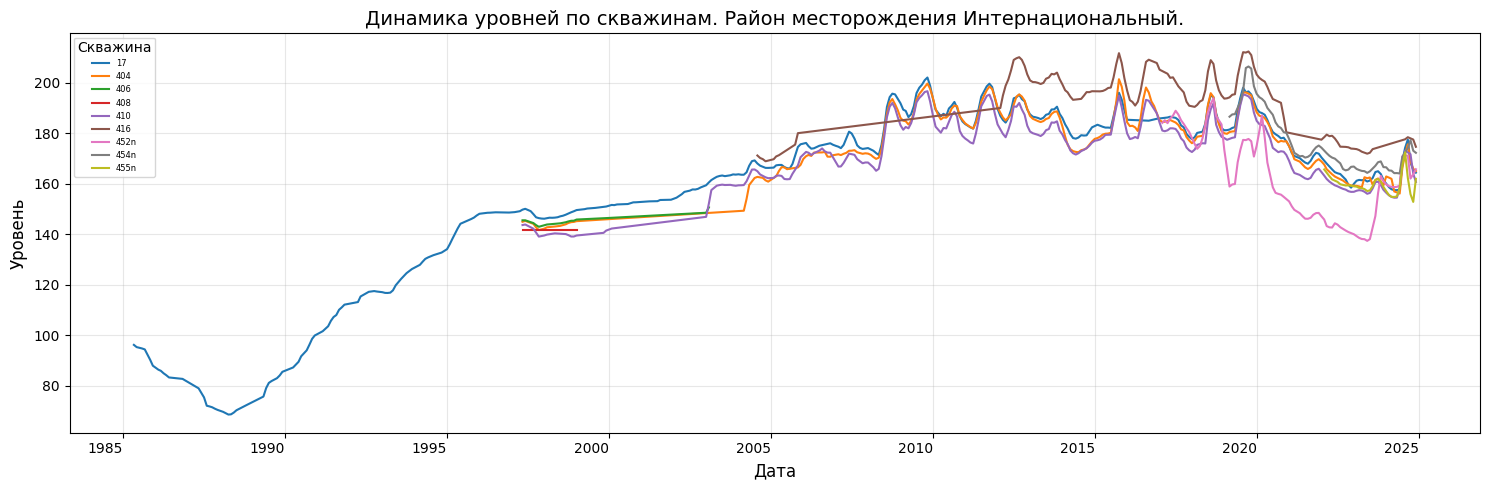

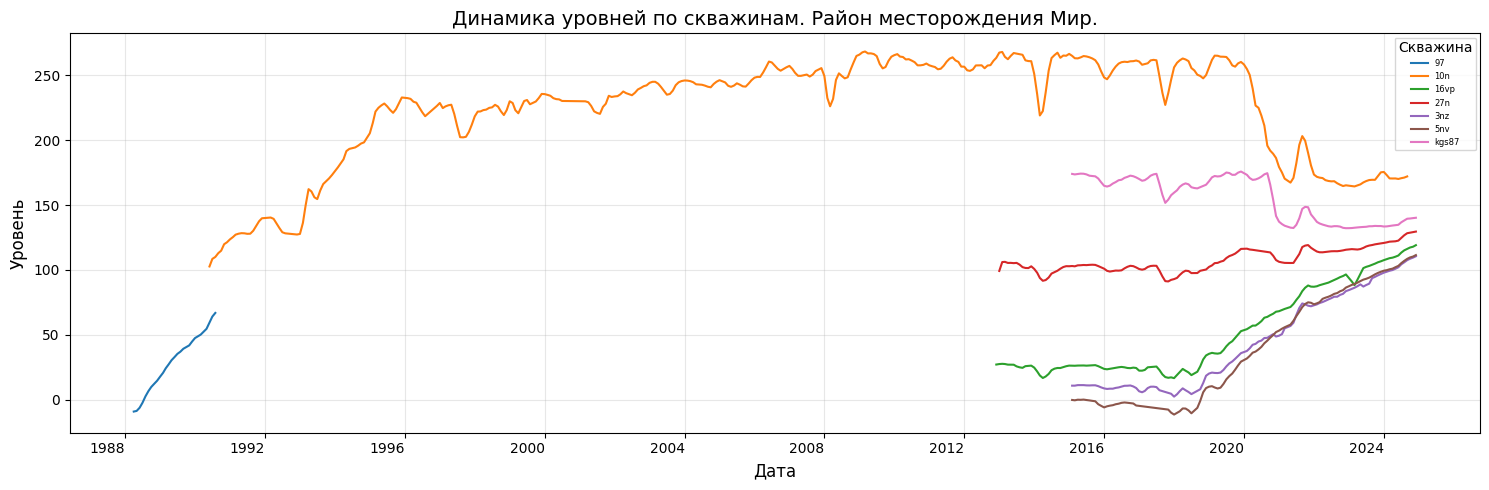

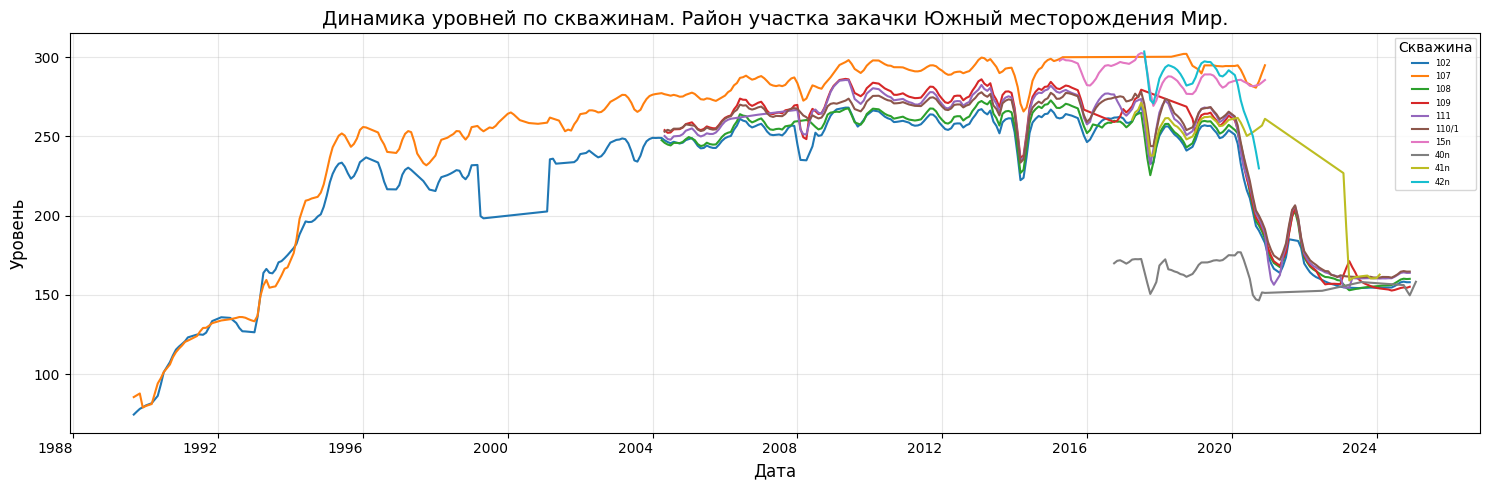

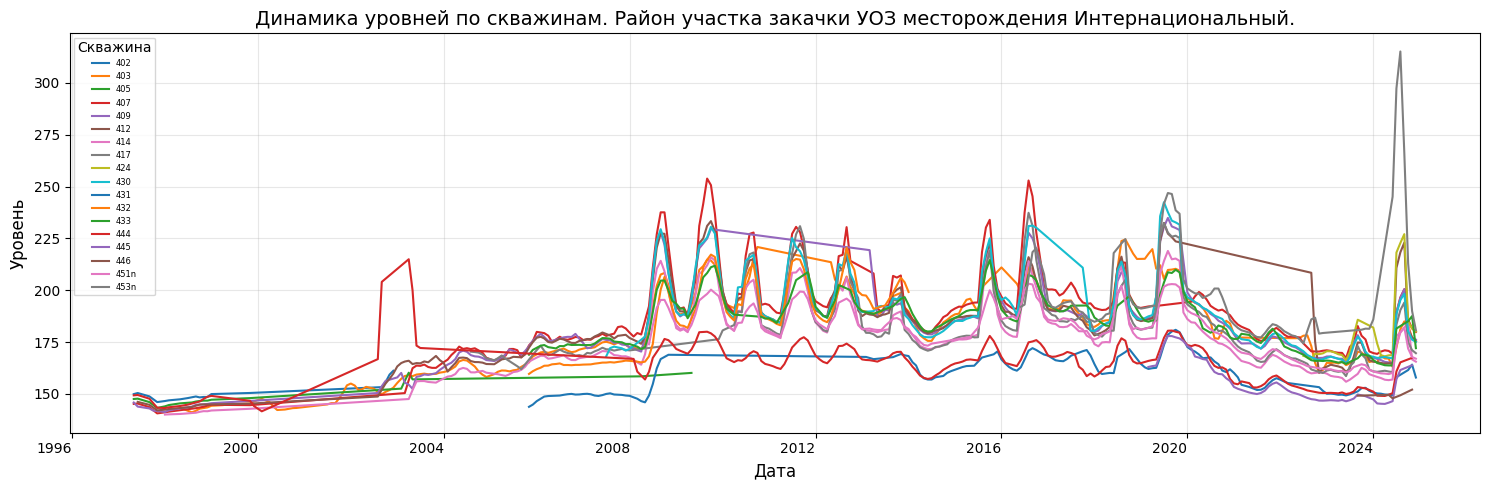

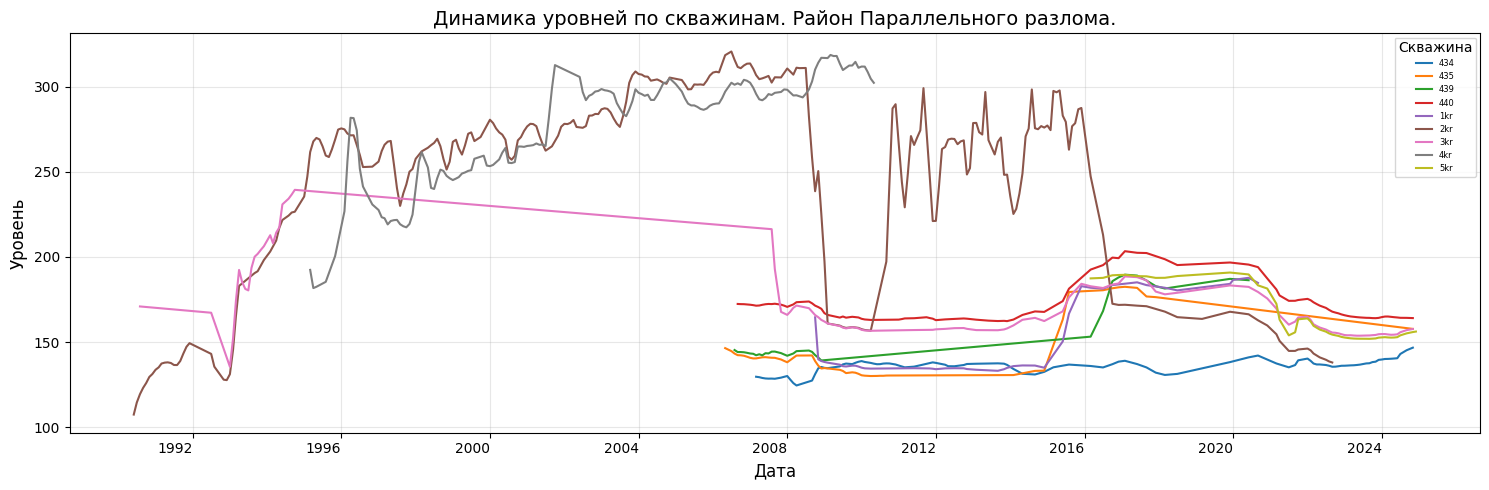

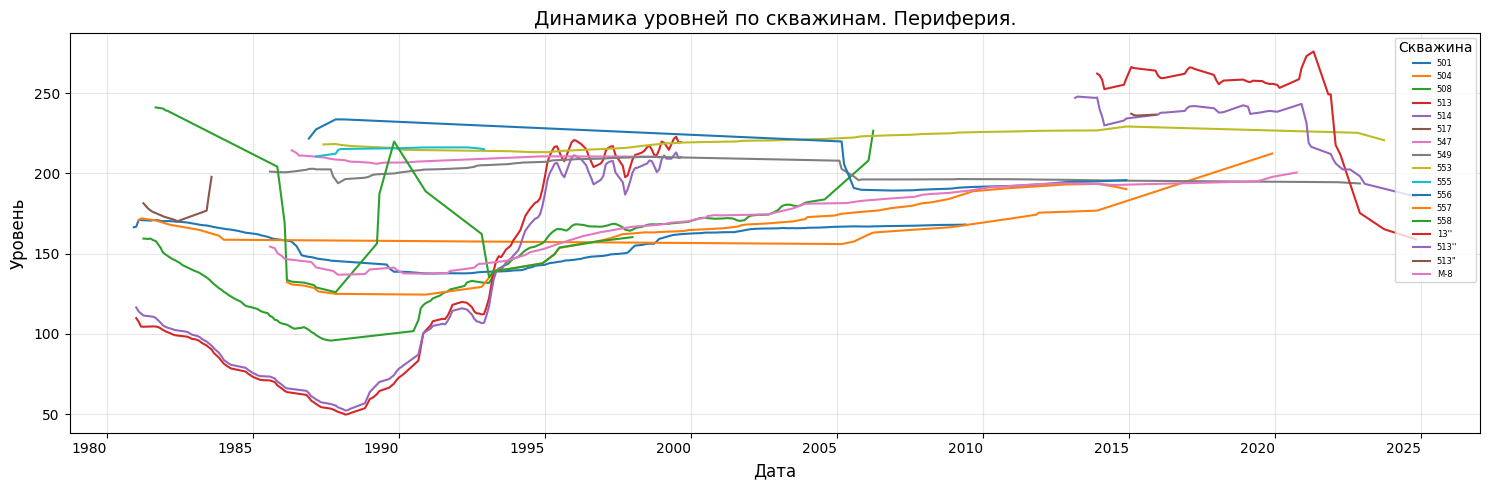

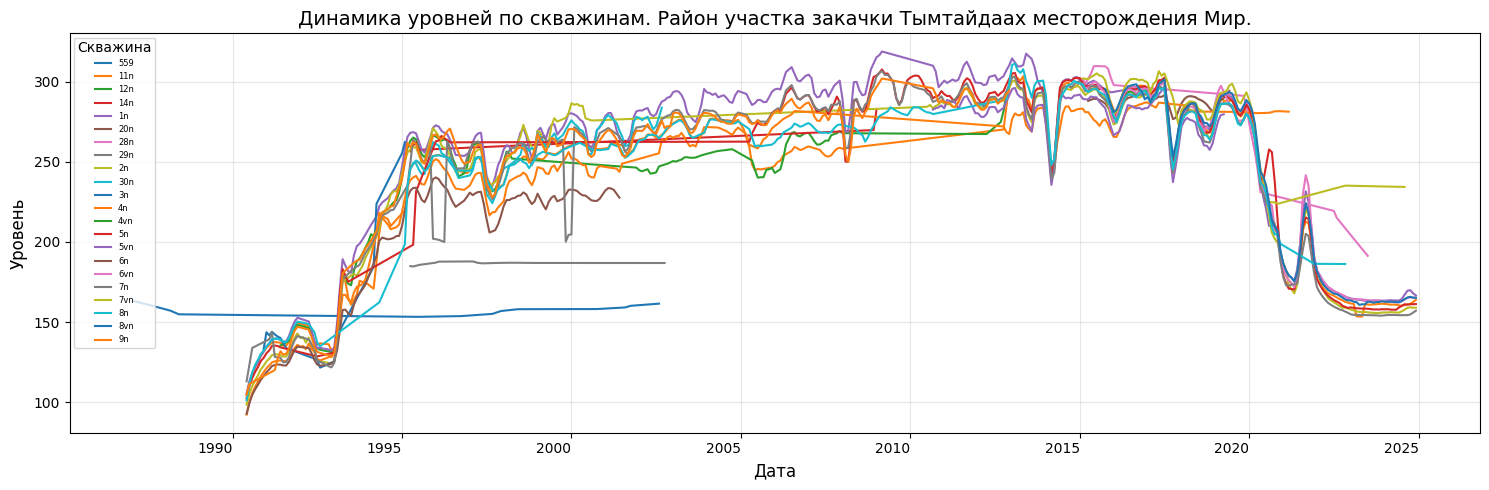

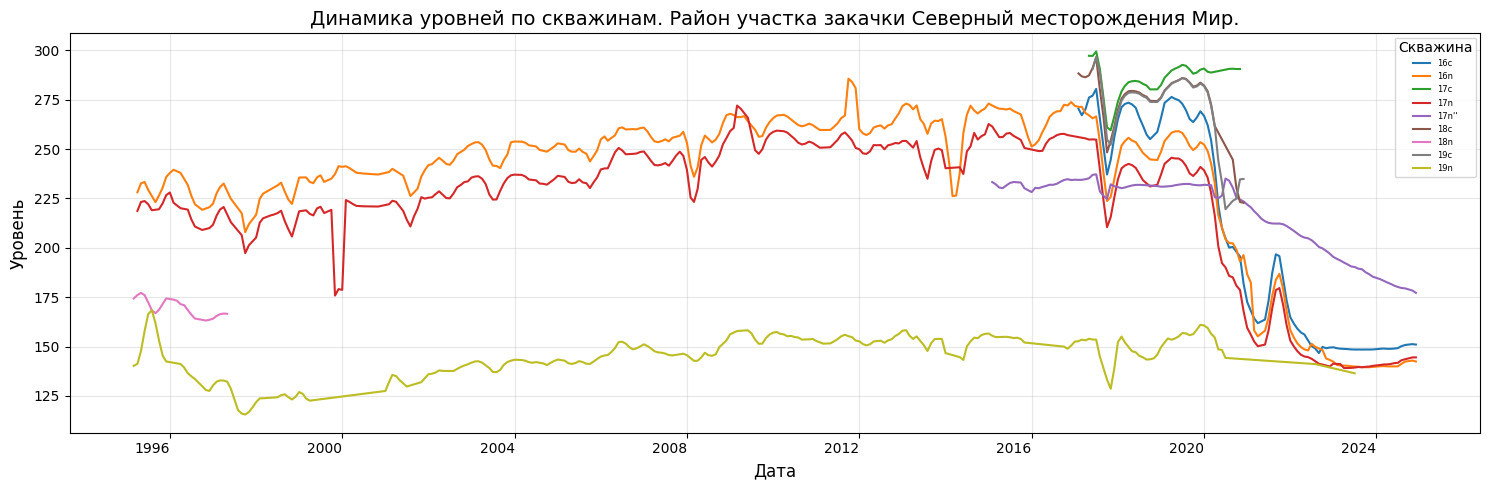

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
# 3. Словарь алиасов для регионов (замените на свои реальные названия)
region_aliases = {
    'Periferia': 'Периферия',
    'CR': 'Район Центрального разлома',
    'PR': 'Район Параллельного разлома',
    'Inter': 'Район месторождения Интернациональный',
    'Mir': 'Район месторождения Мир',
    'SOZ': 'Район участка закачки Тымтайдаах месторождения Мир',
    'UOZ': 'Район участка закачки УОЗ месторождения Интернациональный',
    'South': 'Район участка закачки Южный месторождения Мир',
    'North': 'Район участка закачки Северный месторождения Мир'
}

# 4. Добавляем столбец с русскими названиями регионов
df['region_alias'] = df['region'].map(region_aliases)

# Если какой‑то регион не найден в словаре, оставляем оригинальное название
df['region_alias'] = df['region_alias'].fillna(df['region'])

# 5. Группировка по регионам для создания отдельных графиков
regions = df['region_alias'].unique()

exclude_wells=['f1', 'f2', 'f3', 'f4', '']

for region_alias in regions:
    # Фильтруем данные по текущему региону (используем алиас)
    region_data = df[df['region_alias'] == region_alias]
    
    # Исключаем указанные скважины
    region_data_filtered = region_data[~region_data['name'].isin(exclude_wells)]
    
    # Создаём фигуру для региона
    fig, axes = plt.subplots(figsize=(15, 5))
    
    # 6. Построение сглаженных графиков для каждой скважины в регионе (кроме исключённых)
    for name in region_data_filtered['name'].unique():
        well_data = region_data_filtered[region_data_filtered['name'] == name]
        
        # Отбираем только строки с не пропущенными значениями Head
        valid_data = well_data.dropna(subset=['Head'])
        
        # Сортируем по дате
        valid_data = valid_data.sort_values('date')
        
        # Сглаживание только по реальным точкам
        if len(valid_data) >= 3:  # проверяем, хватит ли точек для скользящего среднего
            valid_data['Head_smoothed'] = valid_data['Head'].rolling(window=3).mean()
        else:
            valid_data['Head_smoothed'] = valid_data['Head']  # если мало точек — берём как есть
        # Строим график (без маркеров, только линия)
        axes.plot(valid_data['date'], valid_data['Head_smoothed'],
                  label=name, linewidth=1.5)
    
    # 7. Оформление графика — теперь используем русский алиас в заголовке
    axes.set_title(f'Динамика уровней по скважинам. {region_alias}.', fontsize=14)
    axes.set_xlabel('Дата', fontsize=12)
    axes.set_ylabel('Уровень', fontsize=12)
    axes.legend(title='Скважина', fontsize=6)
    axes.grid(True, alpha=0.3)
    # Поворот подписей дат для читаемости
    plt.setp(axes.xaxis.get_majorticklabels(), rotation=0, ha='right')
    # Подгонка подписей по краям
    plt.tight_layout()
    # Отображение графика
    plt.show()

In [37]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 3921 entries, 291 to 13457
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name          3921 non-null   str           
 1   Head          3921 non-null   float64       
 2   year          3921 non-null   int64         
 3   month         3921 non-null   int64         
 4   x             3574 non-null   float64       
 5   y             3574 non-null   float64       
 6   z             3574 non-null   float64       
 7   depth         3574 non-null   float64       
 8   top           3323 non-null   float64       
 9   top8          3059 non-null   float64       
 10  bot           3282 non-null   float64       
 11  M             3282 non-null   float64       
 12  m             2737 non-null   float64       
 13  Km            1874 non-null   float64       
 14  a             1320 non-null   float64       
 15  region        3921 non-null   str           
 16  T

In [39]:
df = df[df['date'].dt.year > 2017]

In [41]:
df= df.dropna(subset=['Head'])

In [42]:

# 2. Обработка дат (преобразуем в числовой признак)
df['day_of_year'] = pd.to_datetime(df['date']).dt.dayofyear
df['month'] = pd.to_datetime(df['date']).dt.month

In [43]:
# 3. Кодирование категорий
df = pd.get_dummies(df, columns=['region'], prefix='region')

In [46]:
X = X.drop(columns=['region_alias'])

In [47]:
X.info()

<class 'pandas.DataFrame'>
Index: 3921 entries, 291 to 13457
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   T_mean            3921 non-null   float64
 1   T_min             3921 non-null   float64
 2   T_max             3921 non-null   float64
 3   sum_RRR           3921 non-null   float64
 4   z                 3574 non-null   float64
 5   x                 3574 non-null   float64
 6   y                 3574 non-null   float64
 7   depth             3574 non-null   float64
 8   top               3323 non-null   float64
 9   top8              3059 non-null   float64
 10  bot               3282 non-null   float64
 11  M                 3282 non-null   float64
 12  m                 2737 non-null   float64
 13  Km                1874 non-null   float64
 14  day_of_year       3921 non-null   int32  
 15  month             3921 non-null   int32  
 16  region_Inter      3921 non-null   bool   
 17  region_M

In [45]:

# 4. Разделение на признаки и цель
X = df[['T_mean', 'T_min', 'T_max', 'sum_RRR',
       'z', 'x', 'y', 'depth', 'top', 'top8', 'bot', 'M', 'm', 'Km', 'day_of_year', 'month'] + [col for col in df.columns if col.startswith('region')]]
y = df['Head']



In [48]:
print(y.isna().sum())

0


In [49]:
y_train = y_train.fillna(y_train.mean())

In [50]:
# 5. Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
# Параметры для регрессии (reg:squarederror)
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 8,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Создание и обучение модели
model = xgb.XGBRegressor(**params, random_state=42)
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [57]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Предсказание
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
# 1. MAE
mae = mean_absolute_error(y_test, y_pred)

# 2. RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. MAPE (с защитой от деления на ноль)
def calculate_mape(y_true, y_pred):
    # Исключаем случаи, где истинное значение = 0
    mask = y_true != 0
    y_true_safe = y_true[mask]
    y_pred_safe = y_pred[mask]

    if len(y_true_safe) == 0:
        return float('inf')  # если все значения были нулями

    mape = np.mean(np.abs((y_true_safe - y_pred_safe) / y_true_safe)) * 100
    return mape

mape = calculate_mape(y_test.values, y_pred)

# Вывод результатов
print(f"R² (коэффициент детерминации): {r2:.3f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")



R² (коэффициент детерминации): 0.922
MAE:  9.19
RMSE: 14.74
MAPE: 14.05%


In [53]:
import pandas as pd
import numpy as np

# Предсказание модели
y_pred = model.predict(X_test)

# Создаём временной индекс, если его нет
if not isinstance(X_test.index, pd.DatetimeIndex):
    dates = pd.date_range(
        start='2023-01-01',
        periods=len(y_test),
        freq='D'  # измените частоту при необходимости: 'H' (час), 'M' (месяц) и т. д.
    )
else:
    dates = X_test.index


# Создаём DataFrame с результатами
results_df = pd.DataFrame({
    'Дата': dates,
    'Фактическое_значение': y_test.values.flatten() if hasattr(y_test, 'values') else y_test,
    'Модельное_значение': y_pred.flatten(),
    'Ошибка': (y_test.values if hasattr(y_test, 'values') else y_test) - y_pred,
    'Абсолютная_ошибка': np.abs((y_test.values if hasattr(y_test, 'values') else y_test) - y_pred)
})

# Выводим таблицу
print(results_df.head(10))  # первые 10 строк


        Дата  Фактическое_значение  Модельное_значение     Ошибка  \
0 2023-01-01            154.421613          155.644135  -1.222522   
1 2023-01-02            181.560000          177.420959   4.139041   
2 2023-01-03            281.410000          274.902374   6.507626   
3 2023-01-04             85.980000           74.893059  11.086941   
4 2023-01-05            270.100000          255.787582  14.312418   
5 2023-01-06            277.630000          276.005768   1.624232   
6 2023-01-07            186.690000          203.704468 -17.014468   
7 2023-01-08            161.210000          161.072998   0.137002   
8 2023-01-09            164.920000          103.396034  61.523966   
9 2023-01-10            115.480000          138.128357 -22.648357   

   Абсолютная_ошибка  
0           1.222522  
1           4.139041  
2           6.507626  
3          11.086941  
4          14.312418  
5           1.624232  
6          17.014468  
7           0.137002  
8          61.523966  
9         

In [54]:

# Сохранение полной таблицы в CSV
results_df.to_csv('фактические_и_модельные_значения.csv',
              index=False,
              encoding='utf-8')

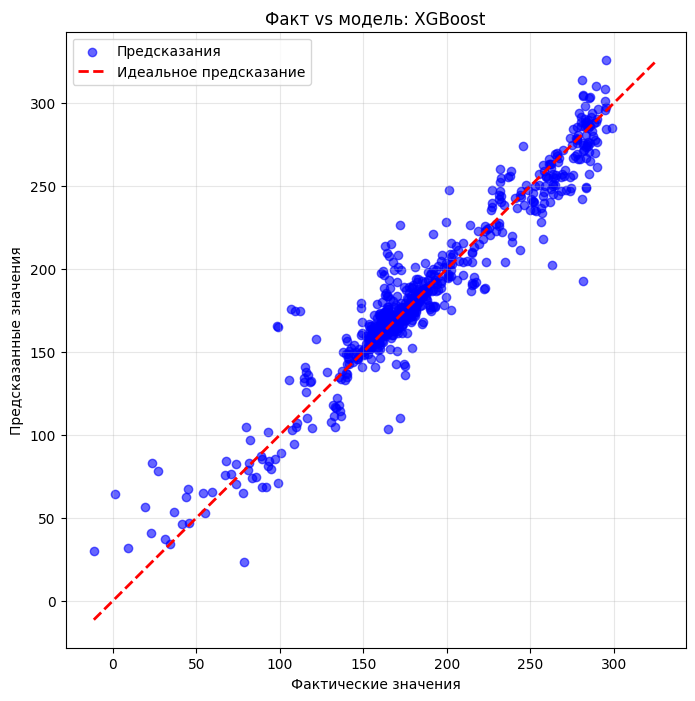

In [55]:
import matplotlib.pyplot as plt

# Предсказание модели
y_pred = model.predict(X_test)

# Создание графика
plt.figure(figsize=(8, 8))

# Точки: фактические vs предсказанные
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Предсказания')

# Линия идеальной точности (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание')

# Оформление
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Факт vs модель: XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
